# Task 1: Data Quality and Preparation
**Objective:** Validate and clean all 6 datasets — check missing values, duplicates, data types, date formats, irrelevant columns, and outliers.

## Step 1: Load All Datasets

In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

df_customers   = pd.read_csv(r"C:\Users\HP\Downloads\Datasets\customers.csv")
df_loans       = pd.read_csv(r"C:\Users\HP\Downloads\Datasets\loans.csv")
df_applications = pd.read_csv(r"C:\Users\HP\Downloads\Datasets\applications.csv", low_memory=False)
df_transactions = pd.read_csv(r"C:\Users\HP\Downloads\Datasets\transactions.csv")
df_defaults     = pd.read_csv(r"C:\Users\HP\Downloads\Datasets\defaults.csv")
df_branches     = pd.read_csv(r"C:\Users\HP\Downloads\Datasets\branches.csv")

datasets = {
    'customers'   : df_customers,
    'loans'       : df_loans,
    'applications': df_applications,
    'transactions': df_transactions,
    'defaults'    : df_defaults,
    'branches'    : df_branches
}

for name, df in datasets.items():
    print(f"{name:15s} -> {df.shape[0]:>7,} rows  x  {df.shape[1]:>2} cols")

customers       ->  70,000 rows  x  14 cols
loans           ->  90,000 rows  x  12 cols
applications    ->  82,600 rows  x  10 cols
transactions    -> 495,000 rows  x   9 cols
defaults        ->   9,000 rows  x   9 cols
branches        ->      50 rows  x   9 cols


## Step 2: Check Missing Values

In [2]:
print("Missing Values Summary\n" + "="*50)
for name, df in datasets.items():
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if missing.empty:
        print(f"\n{name.upper()}: No missing values")
    else:
        print(f"\n{name.upper()}:")
        for col, cnt in missing.items():
            print(f"  {col:<25} {cnt:>6,}  ({cnt/len(df)*100:.1f}%)")

Missing Values Summary

CUSTOMERS: No missing values

LOANS:
  Collateral_Details        30,194  (33.5%)

APPLICATIONS:
  Loan_ID                   12,600  (15.3%)
  Approval_Date             12,600  (15.3%)
  Rejection_Reason          70,000  (84.7%)

TRANSACTIONS: No missing values

DEFAULTS:
  Recovery_Status            2,985  (33.2%)

BRANCHES: No missing values


## Step 3: Check Duplicate Rows

In [3]:
print("Duplicate Rows Check\n" + "="*40)
for name, df in datasets.items():
    dups = df.duplicated().sum()
    status = "None" if dups == 0 else f"{dups} duplicates found"
    print(f"  {name:<15} {status}")

Duplicate Rows Check
  customers       None
  loans           None
  applications    None
  transactions    None
  defaults        None
  branches        None


## Step 4: Fix Data Types — Convert Date Columns

In [4]:
df_loans['Disbursal_Date']        = pd.to_datetime(df_loans['Disbursal_Date'], errors='coerce')
df_loans['Repayment_Start_Date']  = pd.to_datetime(df_loans['Repayment_Start_Date'], errors='coerce')
df_loans['Repayment_End_Date']    = pd.to_datetime(df_loans['Repayment_End_Date'], errors='coerce')

df_applications['Application_Date'] = pd.to_datetime(df_applications['Application_Date'], errors='coerce')
df_applications['Approval_Date']    = pd.to_datetime(df_applications['Approval_Date'], errors='coerce')

df_transactions['Transaction_Date'] = pd.to_datetime(df_transactions['Transaction_Date'], errors='coerce')

df_defaults['Default_Date'] = pd.to_datetime(df_defaults['Default_Date'], errors='coerce')

print("Date columns converted successfully")
print(df_loans[['Disbursal_Date','Repayment_Start_Date','Repayment_End_Date']].dtypes)

Date columns converted successfully
Disbursal_Date          datetime64[ns]
Repayment_Start_Date    datetime64[ns]
Repayment_End_Date      datetime64[ns]
dtype: object


## Step 5: Handle Missing Values

In [5]:
df_loans['Collateral_Details'] = df_loans['Collateral_Details'].fillna('None')
print(f"df_loans -> Collateral_Details missing after fix: {df_loans['Collateral_Details'].isnull().sum()}")

df_applications['Rejection_Reason'] = df_applications['Rejection_Reason'].fillna('Not Applicable')
print(f"df_applications -> Rejection_Reason missing after fix: {df_applications['Rejection_Reason'].isnull().sum()}")

print(f"df_applications -> Loan_ID missing (rejected apps, expected): {df_applications['Loan_ID'].isnull().sum()}")
print(f"df_applications -> Approval_Date missing (rejected apps, expected): {df_applications['Approval_Date'].isnull().sum()}")

df_defaults['Recovery_Status'] = df_defaults['Recovery_Status'].fillna('Pending')
print(f"df_defaults -> Recovery_Status missing after fix: {df_defaults['Recovery_Status'].isnull().sum()}")

df_loans -> Collateral_Details missing after fix: 0
df_applications -> Rejection_Reason missing after fix: 0
df_applications -> Loan_ID missing (rejected apps, expected): 12600
df_applications -> Approval_Date missing (rejected apps, expected): 12600
df_defaults -> Recovery_Status missing after fix: 0


## Step 6: Remove Irrelevant Columns

In [6]:
pii_cols = ['Full_Name', 'Contact_Number', 'Email', 'Address']
df_customers.drop(columns=pii_cols, inplace=True, errors='ignore')
print(f"Dropped PII columns: {pii_cols}")

df_customers['Account_Tenure_Years'] = df_customers['Account_Tenure'].str.extract(r'(\d+)').astype(int)
df_customers.drop(columns=['Account_Tenure'], inplace=True, errors='ignore')
print("Converted Account_Tenure -> Account_Tenure_Years (int)")

print(f"\ndf_customers columns: {list(df_customers.columns)}")

Dropped PII columns: ['Full_Name', 'Contact_Number', 'Email', 'Address']
Converted Account_Tenure -> Account_Tenure_Years (int)

df_customers columns: ['Customer_ID', 'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income', 'Credit_Score', 'Region', 'Relationship_Manager_ID', 'Account_Tenure_Years']


## Step 7: Outlier Detection (IQR Method)

In [7]:
numeric_cols = {
    'df_loans'       : ['Loan_Amount', 'Interest_Rate', 'EMI_Amount', 'Overdue_Amount'],
    'df_defaults'    : ['Default_Amount', 'Recovery_Amount'],
    'df_transactions': ['Amount', 'Overdue_Fee'],
    'df_customers'   : ['Credit_Score', 'Annual_Income', 'Age'],
}

name_map = {
    'df_loans': df_loans, 'df_defaults': df_defaults,
    'df_transactions': df_transactions, 'df_customers': df_customers
}

print(f"{'Dataset':<18} {'Column':<22} {'Min':>10} {'Max':>12} {'Outliers':>10}")
print("-" * 78)

for df_name, cols in numeric_cols.items():
    df = name_map[df_name]
    for col in cols:
        s = df[col].dropna()
        Q1, Q3 = s.quantile(0.25), s.quantile(0.75)
        IQR = Q3 - Q1
        lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
        outliers = ((s < lower) | (s > upper)).sum()
        flag = " (outliers found)" if outliers > 0 else ""
        print(f"{df_name:<18} {col:<22} {s.min():>10,.0f} {s.max():>12,.0f} {outliers:>10}{flag}")

Dataset            Column                        Min          Max   Outliers
------------------------------------------------------------------------------
df_loans           Loan_Amount                50,026    4,999,958          0
df_loans           Interest_Rate                   7           15          0
df_loans           EMI_Amount                  2,001      100,000          0
df_loans           Overdue_Amount                  0       49,999          0
df_defaults        Default_Amount              5,010       99,997          0
df_defaults        Recovery_Amount                 0       50,000          0
df_transactions    Amount                      1,000       50,000          0
df_transactions    Overdue_Fee                     0        5,000          0
df_customers       Credit_Score                  300          850          0
df_customers       Annual_Income             200,005    1,999,950          0
df_customers       Age                            18           70         

## Step 8: Final Cleaned Dataset Summary

In [8]:
datasets = {
    'df_customers'   : df_customers,
    'df_loans'       : df_loans,
    'df_applications': df_applications,
    'df_transactions': df_transactions,
    'df_defaults'    : df_defaults,
    'df_branches'    : df_branches
}

print("Final Cleaned Dataset Summary")
print("=" * 60)
for name, df in datasets.items():
    missing = df.isnull().sum().sum()
    dups    = df.duplicated().sum()
    print(f"{name:<20} Rows: {len(df):>7,}  Cols: {df.shape[1]:>2}  "
          f"Missing: {missing:>5}  Duplicates: {dups}")

print("\nAll datasets cleaned and ready for analysis.")

Final Cleaned Dataset Summary
df_customers         Rows:  70,000  Cols: 10  Missing:     0  Duplicates: 0
df_loans             Rows:  90,000  Cols: 12  Missing:     0  Duplicates: 0
df_applications      Rows:  82,600  Cols: 10  Missing: 25200  Duplicates: 0
df_transactions      Rows: 495,000  Cols:  9  Missing:     0  Duplicates: 0
df_defaults          Rows:   9,000  Cols:  9  Missing:     0  Duplicates: 0
df_branches          Rows:      50  Cols:  9  Missing:     0  Duplicates: 0

All datasets cleaned and ready for analysis.


**TASK 2 : Descriptive Analysis**

**Objective:**  
Summarize and visualize key metrics:
- Distribution of **Loan Amount**, **EMI Amount**, and **Credit Score**
- **Regional trends** in loan disbursement and defaults
- **Monthly trends** in loan approvals and disbursements

In [9]:
df = df_loans.merge(df_customers, on="Customer_ID", how="left")
df = df.merge(df_defaults[['Loan_ID','Default_ID']], on="Loan_ID", how="left")

df['Default_Flag'] = df['Default_ID'].notna().astype(int)

In [10]:
df = df_loans.merge(df_customers, on="Customer_ID", how="left")
df = df.merge(df_defaults[['Loan_ID','Default_ID']], on="Loan_ID", how="left")

In [11]:
print(df.columns)

Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income',
       'Credit_Score', 'Region', 'Relationship_Manager_ID',
       'Account_Tenure_Years', 'Default_ID'],
      dtype='object')


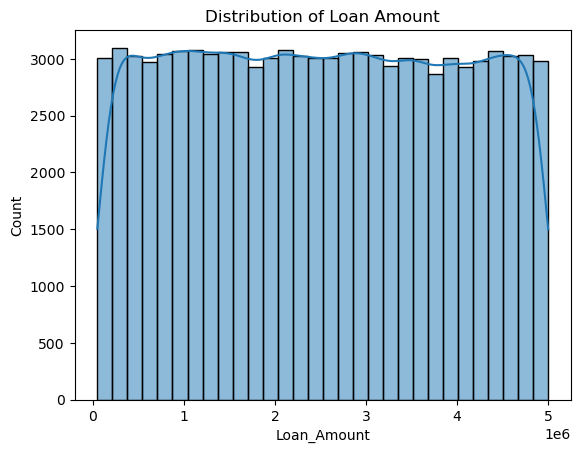

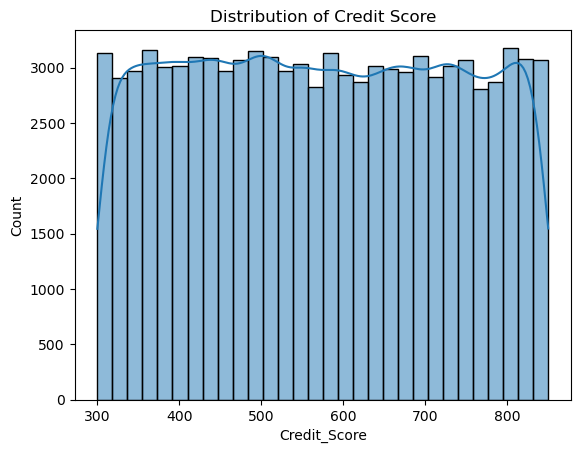

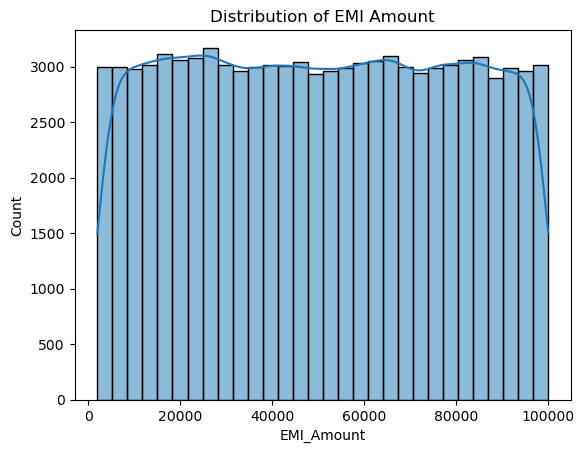

In [12]:
# Loan Amount
plt.figure()
sns.histplot(df['Loan_Amount'], bins=30, kde=True)
plt.title("Distribution of Loan Amount")
plt.show()

# Credit Score
plt.figure()
sns.histplot(df['Credit_Score'], bins=30, kde=True)
plt.title("Distribution of Credit Score")
plt.show()

# EMI Amount (already exists)
plt.figure()
sns.histplot(df['EMI_Amount'], bins=30, kde=True)
plt.title("Distribution of EMI Amount")
plt.show()

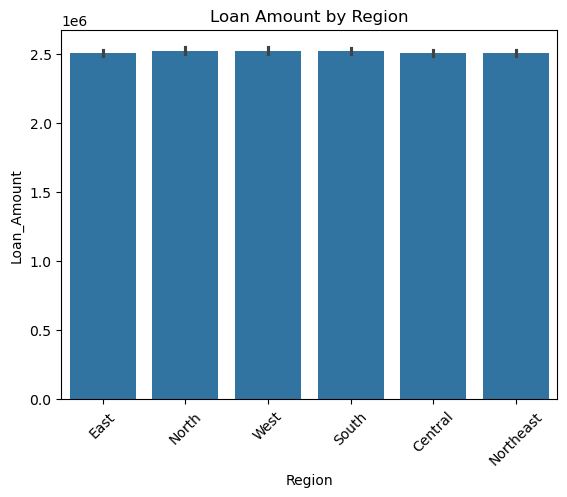

In [13]:
plt.figure()
sns.barplot(data=df, x='Region', y='Loan_Amount')
plt.title("Loan Amount by Region")
plt.xticks(rotation=45)
plt.show()

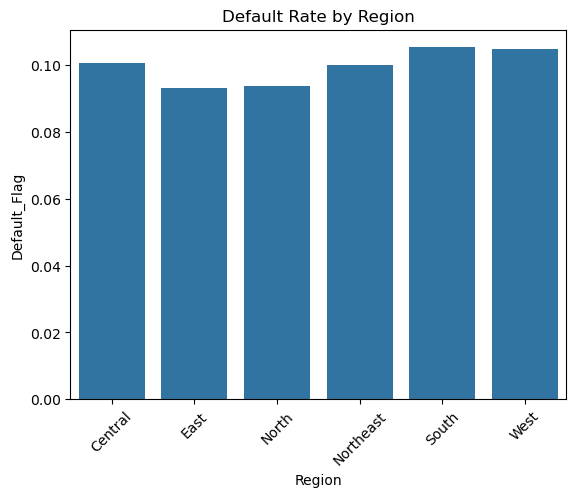

In [14]:
df['Default_Flag'] = df['Default_ID'].notna().astype(int)

region_default = df.groupby('Region')['Default_Flag'].mean().reset_index()

plt.figure()
sns.barplot(data=region_default, x='Region', y='Default_Flag')
plt.title("Default Rate by Region")
plt.xticks(rotation=45)
plt.show()

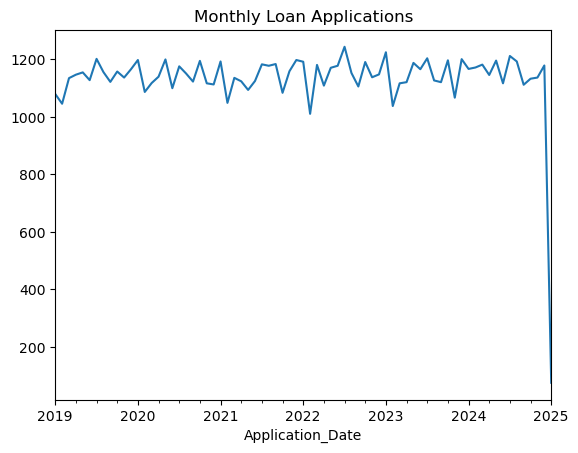

In [15]:
df_applications['Application_Date'] = pd.to_datetime(df_applications['Application_Date'])

monthly_apps = df_applications.groupby(
    df_applications['Application_Date'].dt.to_period('M')
).size()

monthly_apps.plot()
plt.title("Monthly Loan Applications")
plt.show()

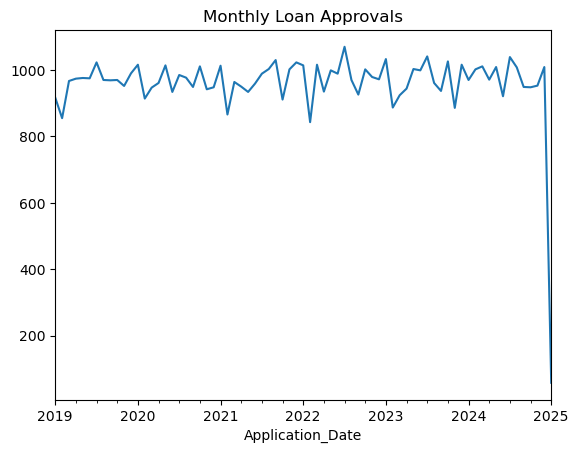

In [16]:
approved = df_applications[df_applications['Approval_Status'] == 'Approved']

monthly_approved = approved.groupby(
    approved['Application_Date'].dt.to_period('M')
).size()

monthly_approved.plot()
plt.title("Monthly Loan Approvals")
plt.show()

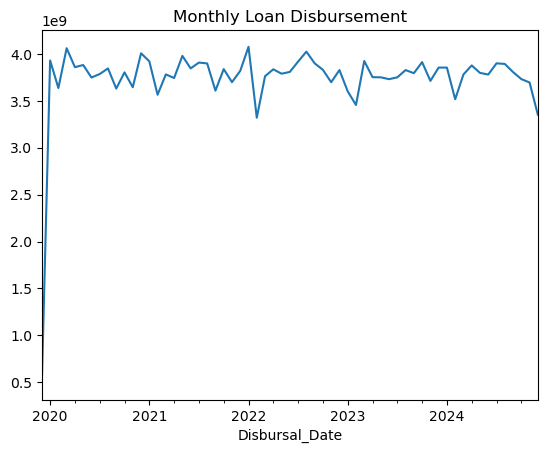

In [17]:
df['Disbursal_Date'] = pd.to_datetime(df['Disbursal_Date'])

monthly_disb = df.groupby(
    df['Disbursal_Date'].dt.to_period('M')
)['Loan_Amount'].sum()

monthly_disb.plot()
plt.title("Monthly Loan Disbursement")
plt.show()

**TASK 3 : Default Risk Analysis**

**Correlation Between Loan Attributes and Defaults:**  
**Pairwise Correlation Analysis:**  
**Correlation Between Branch Metrics and Defaults:**  

In [18]:

df['Default_Flag'] = df['Default_ID'].notna().astype(int)

In [19]:
corr_df = df[['Loan_Amount','Interest_Rate','Credit_Score','Default_Flag']].corr()

print(corr_df)

               Loan_Amount  Interest_Rate  Credit_Score  Default_Flag
Loan_Amount       1.000000      -0.003451      0.000262     -0.002401
Interest_Rate    -0.003451       1.000000      0.002498     -0.004763
Credit_Score      0.000262       0.002498      1.000000     -0.001724
Default_Flag     -0.002401      -0.004763     -0.001724      1.000000


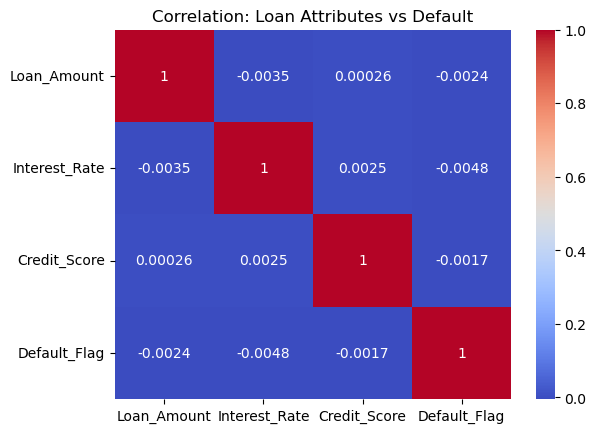

In [20]:
plt.figure()
sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.title("Correlation: Loan Attributes vs Default")
plt.show()

In [21]:
df = df.merge(df_defaults[['Loan_ID','Default_Amount']], on='Loan_ID', how='left')

In [22]:
pair_df = df[['EMI_Amount','Overdue_Amount','Default_Amount','Default_Flag']].corr()

print(pair_df)

                EMI_Amount  Overdue_Amount  Default_Amount  Default_Flag
EMI_Amount        1.000000        0.000567        0.009029      0.001176
Overdue_Amount    0.000567        1.000000       -0.007614      0.001031
Default_Amount    0.009029       -0.007614        1.000000           NaN
Default_Flag      0.001176        0.001031             NaN      1.000000


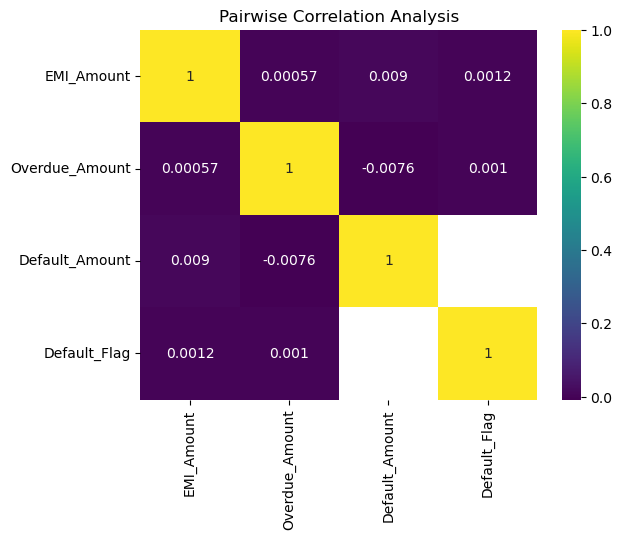

In [23]:
plt.figure()
sns.heatmap(pair_df, annot=True, cmap='viridis')
plt.title("Pairwise Correlation Analysis")
plt.show()

In [24]:
df_branches['Default_Rate'] = df_branches['Delinquent_Loans'] / df_branches['Total_Active_Loans']

In [25]:
branch_corr = df_branches[['Delinquent_Loans',
                        'Loan_Disbursement_Amount',
                        'Total_Active_Loans',
                        'Default_Rate']].corr()

print(branch_corr)

                          Delinquent_Loans  Loan_Disbursement_Amount  \
Delinquent_Loans                  1.000000                  0.023648   
Loan_Disbursement_Amount          0.023648                  1.000000   
Total_Active_Loans               -0.101195                  0.082685   
Default_Rate                      0.473941                  0.042768   

                          Total_Active_Loans  Default_Rate  
Delinquent_Loans                   -0.101195      0.473941  
Loan_Disbursement_Amount            0.082685      0.042768  
Total_Active_Loans                  1.000000     -0.599700  
Default_Rate                       -0.599700      1.000000  


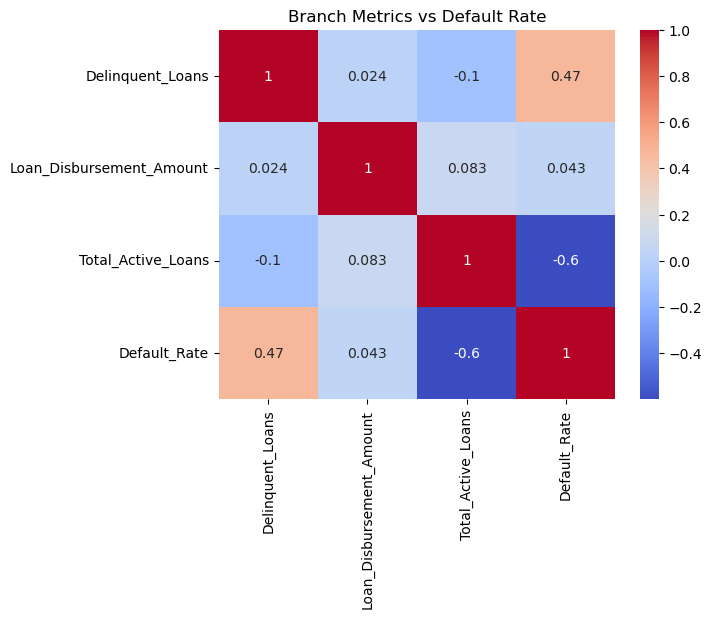

In [26]:
plt.figure()
sns.heatmap(branch_corr, annot=True, cmap='coolwarm')
plt.title("Branch Metrics vs Default Rate")
plt.show()

**TASK 4 : Branch and Regional Performance**

**Rank branches:**  

In [27]:
df_branches['Default_Rate'] = df_branches['Delinquent_Loans'] / df_branches['Total_Active_Loans']

In [28]:
df_defaults['Recovery_Rate'] = df_defaults['Recovery_Amount'] / df_defaults['Default_Amount']

recovery_rate = df_defaults['Recovery_Rate'].mean()
print("Average Recovery Rate:", recovery_rate)

Average Recovery Rate: 0.40455751045929983


In [29]:
top_disbursement = df_branches.sort_values(by='Loan_Disbursement_Amount', ascending=False)

top_disbursement[['Branch_Name','Loan_Disbursement_Amount']].head()

,Branch_Name,Loan_Disbursement_Amount
35,Kara-Bahl,499562869
13,"Bhatti, Rau and Sem",482327541
11,Kaul Inc,465469874
47,Chawla-Subramanian,464419943
34,"Malhotra, Boase and Malhotra",449109596


In [30]:
best_processing = df_branches.sort_values(by='Avg_Processing_Time')

best_processing[['Branch_Name','Avg_Processing_Time']].head()

,Branch_Name,Avg_Processing_Time
49,Sani-Kale,1
46,Chawla-Tandon,2
41,Kar-Jaggi,2
17,"Sandhu, Magar and Sachdeva",2
44,Solanki-Shah,3


In [31]:
low_default = df_branches.sort_values(by='Default_Rate')

low_default[['Branch_Name','Default_Rate']].head()

,Branch_Name,Default_Rate
39,"Dada, Chander and Bhatt",0.005173
29,Kakar-Dutta,0.009735
46,Chawla-Tandon,0.014376
26,Kapadia-Ramakrishnan,0.021687
45,Badal Group,0.026092


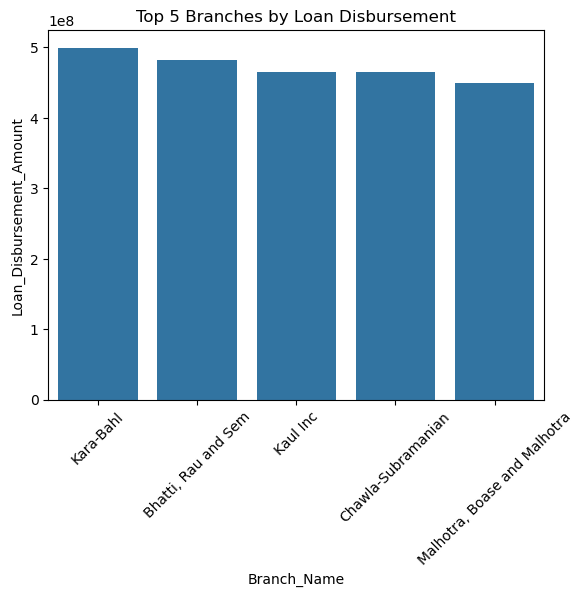

In [32]:
top5 = top_disbursement.head(5)

plt.figure()
sns.barplot(data=top5, x='Branch_Name', y='Loan_Disbursement_Amount')
plt.title("Top 5 Branches by Loan Disbursement")
plt.xticks(rotation=45)
plt.show()

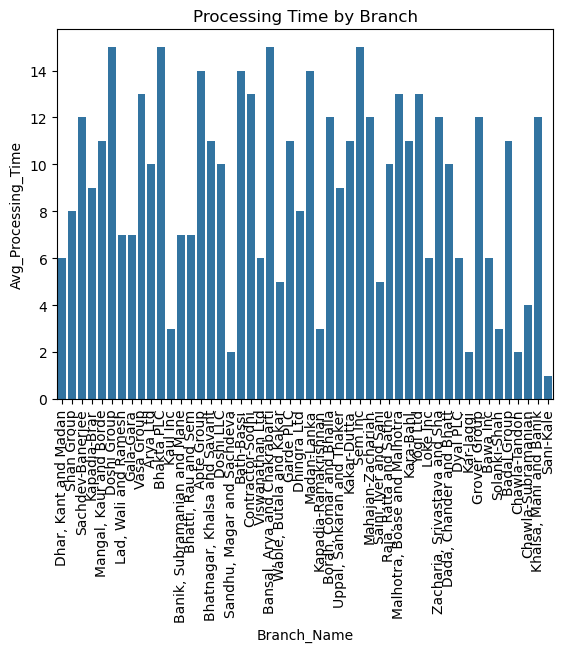

In [33]:
plt.figure()
sns.barplot(data=df_branches, x='Branch_Name', y='Avg_Processing_Time')
plt.title("Processing Time by Branch")
plt.xticks(rotation=90)
plt.show()

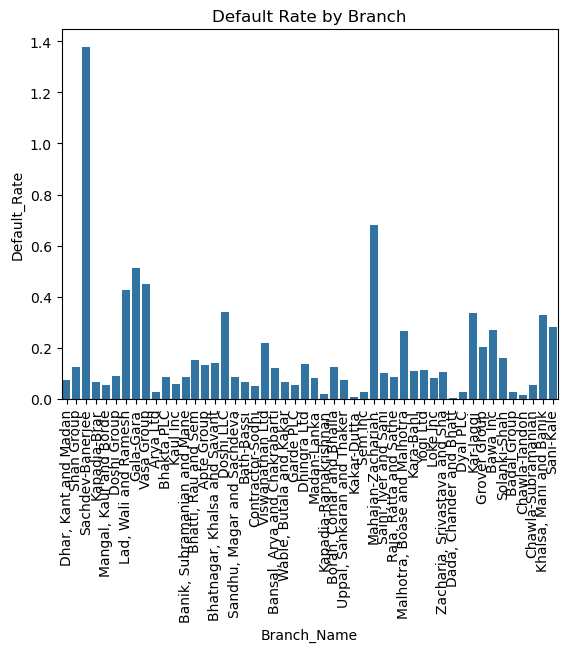

In [34]:
plt.figure()
sns.barplot(data=df_branches, x='Branch_Name', y='Default_Rate')
plt.title("Default Rate by Branch")
plt.xticks(rotation=90)
plt.show()

In [35]:
region_perf = df_branches.groupby('Region').agg({
    'Loan_Disbursement_Amount':'sum',
    'Delinquent_Loans':'sum',
    'Total_Active_Loans':'sum'
}).reset_index()

region_perf['Default_Rate'] = region_perf['Delinquent_Loans'] / region_perf['Total_Active_Loans']

region_perf

,Region,Loan_Disbursement_Amount,Delinquent_Loans,Total_Active_Loans,Default_Rate
0,Central,3316048302,994,8715,0.114056
1,East,2006676282,756,8929,0.084668
2,North,3296073904,1504,11965,0.125700
3,Northeast,442827845,487,5174,0.094124
4,South,1694906506,846,9235,0.091608
5,West,1990828641,441,6861,0.064276


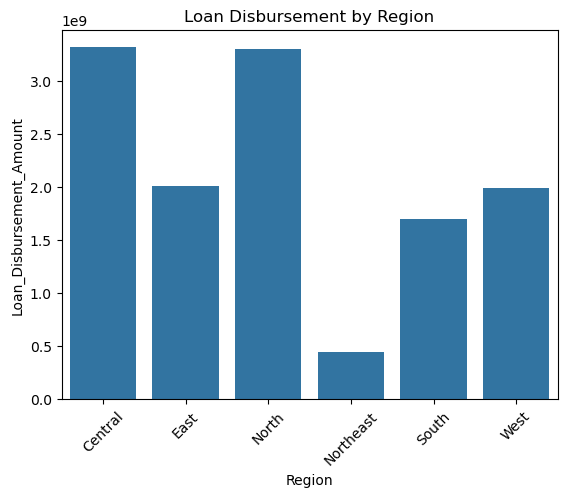

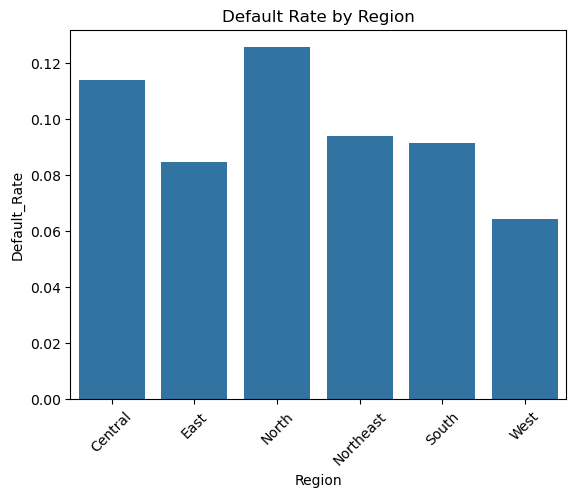

In [36]:
plt.figure()
sns.barplot(data=region_perf, x='Region', y='Loan_Disbursement_Amount')
plt.title("Loan Disbursement by Region")
plt.xticks(rotation=45)
plt.show()

plt.figure()
sns.barplot(data=region_perf, x='Region', y='Default_Rate')
plt.title("Default Rate by Region")
plt.xticks(rotation=45)
plt.show()

**TASK 5 : Customer Segmentation**

**Segment customers by income, credit score, and loan status.
● Identify high-risk and high-value customer groups.
● Analyze repayment behavior across segments:**  

In [37]:
# Income Segments
df['Income_Group'] = pd.cut(df['Annual_Income'],
                           bins=[0,500000,1000000,5000000],
                           labels=['Low','Medium','High'])

# Credit Score Segments
df['Credit_Group'] = pd.cut(df['Credit_Score'],
                           bins=[0,600,750,900],
                           labels=['Low','Medium','High'])

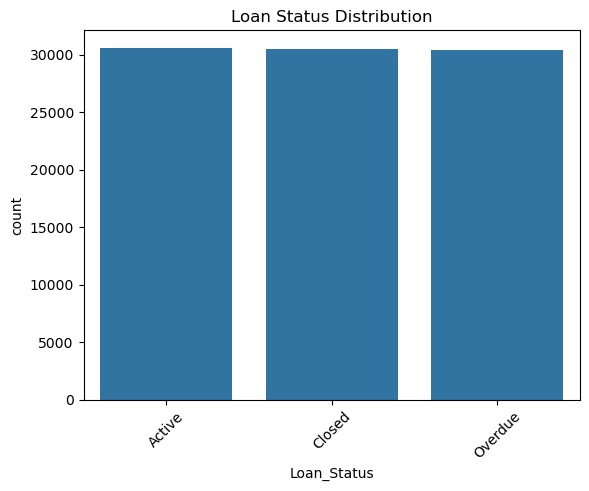

In [38]:
sns.countplot(data=df, x='Loan_Status')
plt.title("Loan Status Distribution")
plt.xticks(rotation=45)
plt.show()

In [39]:
high_risk = df[(df['Credit_Group']=='Low') & (df['Income_Group']=='Low')]

print("High Risk Customers:", high_risk.shape[0])

High Risk Customers: 8449


In [40]:
high_value = df[(df['Credit_Group']=='High') & (df['Income_Group']=='High')]

print("High Value Customers:", high_value.shape[0])

High Value Customers: 9282


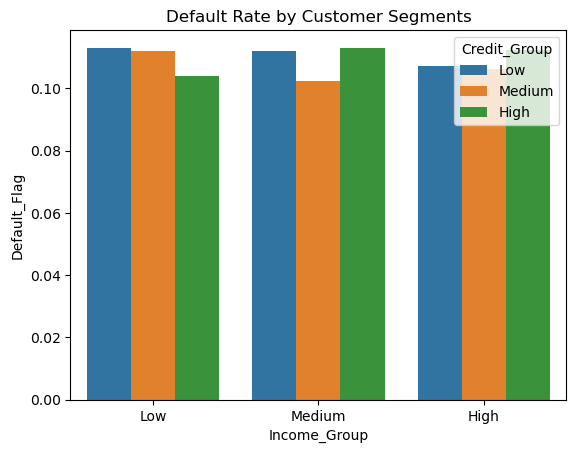

In [41]:
df['Default_Flag'] = df['Default_ID'].notna().astype(int)

segment_default = df.groupby(['Income_Group','Credit_Group'])['Default_Flag'].mean().reset_index()

sns.barplot(data=segment_default, x='Income_Group', y='Default_Flag', hue='Credit_Group')
plt.title("Default Rate by Customer Segments")
plt.show()

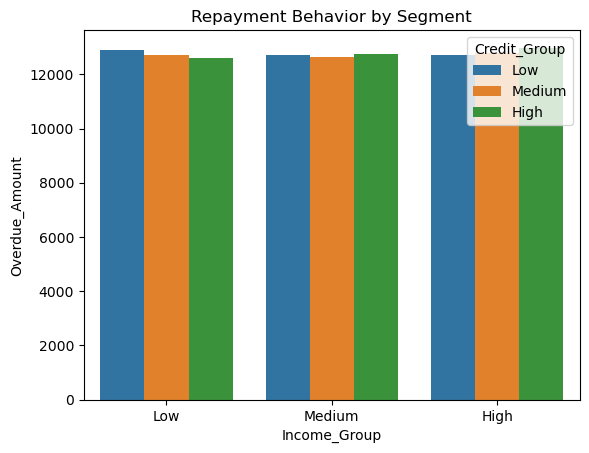

In [42]:
repayment = df.groupby(['Income_Group','Credit_Group'])['Overdue_Amount'].mean().reset_index()

sns.barplot(data=repayment, x='Income_Group', y='Overdue_Amount', hue='Credit_Group')
plt.title("Repayment Behavior by Segment")
plt.show()

**TASK 6 : Advanced Statistical Analysis**

**Correlation Analysis for Default Risks.
●Pairwise Correlation Heatmap.
● Branch-Level Correlation:**  

In [43]:
corr_df = df[['Credit_Score',
              'Loan_Amount',
              'Interest_Rate',
              'Overdue_Amount',
              'Default_Flag']].corr()

print(corr_df)

                Credit_Score  Loan_Amount  Interest_Rate  Overdue_Amount  \
Credit_Score        1.000000     0.000445       0.002633        0.002927   
Loan_Amount         0.000445     1.000000      -0.003917        0.007877   
Interest_Rate       0.002633    -0.003917       1.000000       -0.003751   
Overdue_Amount      0.002927     0.007877      -0.003751        1.000000   
Default_Flag       -0.002115    -0.000484      -0.006374        0.001031   

                Default_Flag  
Credit_Score       -0.002115  
Loan_Amount        -0.000484  
Interest_Rate      -0.006374  
Overdue_Amount      0.001031  
Default_Flag        1.000000  


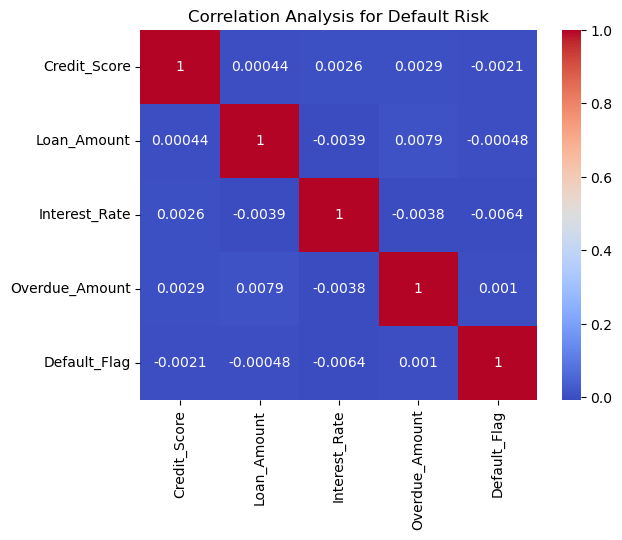

In [44]:
plt.figure()
sns.heatmap(corr_df, annot=True, cmap='coolwarm')
plt.title("Correlation Analysis for Default Risk")
plt.show()

In [45]:
# Add Recovery Rate
df_defaults['Recovery_Rate'] = df_defaults['Recovery_Amount'] / df_defaults['Default_Amount']

# Merge if not already
df = df.merge(df_defaults[['Loan_ID','Default_Amount','Recovery_Rate']], 
              on='Loan_ID', how='left')

In [46]:
df = df.merge(df_defaults[['Loan_ID','Default_Amount']], 
              on='Loan_ID', how='left')

In [47]:
pair_df = df[['EMI_Amount',
              'Default_Amount',
              'Recovery_Rate',
              'Default_Flag']].corr()

print(pair_df)

                EMI_Amount  Default_Amount  Recovery_Rate  Default_Flag
EMI_Amount        1.000000        0.014955       0.010352     -0.004294
Default_Amount    0.014955        1.000000      -0.278536           NaN
Recovery_Rate     0.010352       -0.278536       1.000000           NaN
Default_Flag     -0.004294             NaN            NaN      1.000000


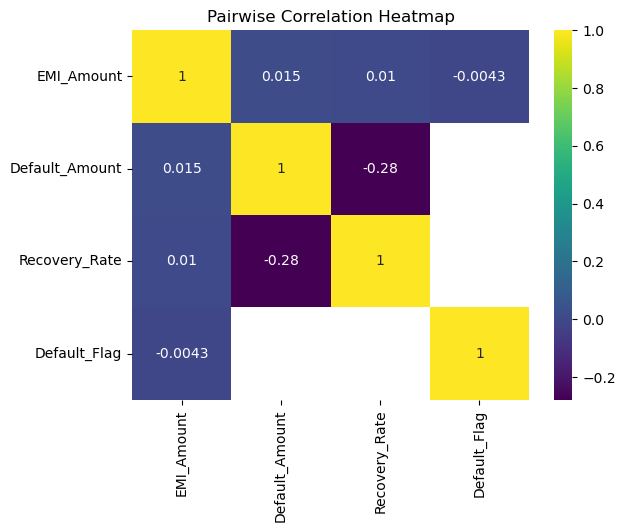

In [48]:
plt.figure()
sns.heatmap(pair_df, annot=True, cmap='viridis')
plt.title("Pairwise Correlation Heatmap")
plt.show()

In [49]:
df_branches['Default_Rate'] = df_branches['Delinquent_Loans'] / df_branches['Total_Active_Loans']

In [50]:
branch_corr = df_branches[['Delinquent_Loans',
                        'Loan_Disbursement_Amount',
                        'Default_Rate']].corr()

print(branch_corr)

                          Delinquent_Loans  Loan_Disbursement_Amount  \
Delinquent_Loans                  1.000000                  0.023648   
Loan_Disbursement_Amount          0.023648                  1.000000   
Default_Rate                      0.473941                  0.042768   

                          Default_Rate  
Delinquent_Loans              0.473941  
Loan_Disbursement_Amount      0.042768  
Default_Rate                  1.000000  


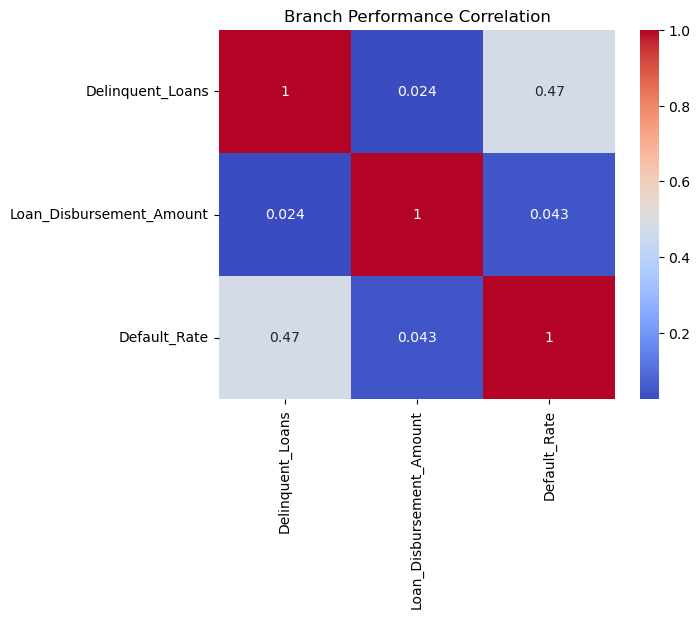

In [51]:
plt.figure()
sns.heatmap(branch_corr, annot=True, cmap='coolwarm')
plt.title("Branch Performance Correlation")
plt.show()

**TASK 7 : Transaction and Recovery Analysis**


In [52]:
print(df_transactions.columns)

Index(['Transaction_ID', 'Loan_ID', 'Customer_ID', 'Transaction_Date',
       'Payment_Type', 'Amount', 'Overdue_Fee', 'Remaining_Balance',
       'Mode_of_Payment'],
      dtype='object')


In [53]:
df_transactions['Transaction_Date'] = pd.to_datetime(df_transactions['Transaction_Date'], errors='coerce')

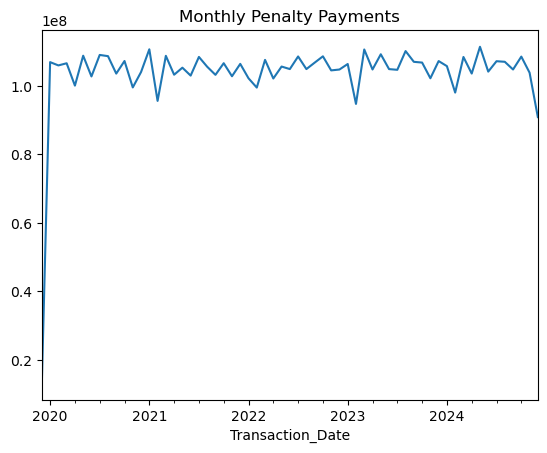

In [54]:
# Step 1: Convert original dataframe
df_transactions['Transaction_Date'] = pd.to_datetime(
    df_transactions['Transaction_Date'], errors='coerce'
)

# Step 2: Create filtered dataframe AFTER conversion
penalty_txn = df_transactions[
    df_transactions['Payment_Type'].str.contains('Penalty', case=False, na=False)
].copy()

# Step 3: (IMPORTANT) ensure datetime in filtered df
penalty_txn['Transaction_Date'] = pd.to_datetime(
    penalty_txn['Transaction_Date'], errors='coerce'
)

# Step 4: Now group
monthly_penalty = penalty_txn.groupby(
    penalty_txn['Transaction_Date'].dt.to_period('M')
)['Amount'].sum()

monthly_penalty.plot()
plt.title("Monthly Penalty Payments")
plt.show()

**TASK 8 : EMI Analysis**

In [55]:
df['Default_Flag'] = df['Default_ID'].notna().astype(int)

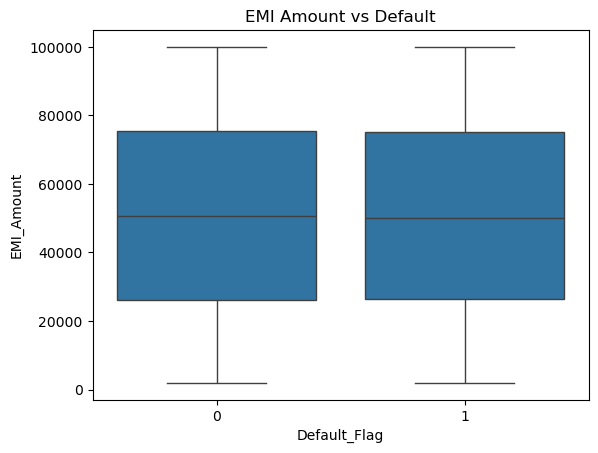

In [56]:
sns.boxplot(data=df, x='Default_Flag', y='EMI_Amount')
plt.title("EMI Amount vs Default")
plt.show()

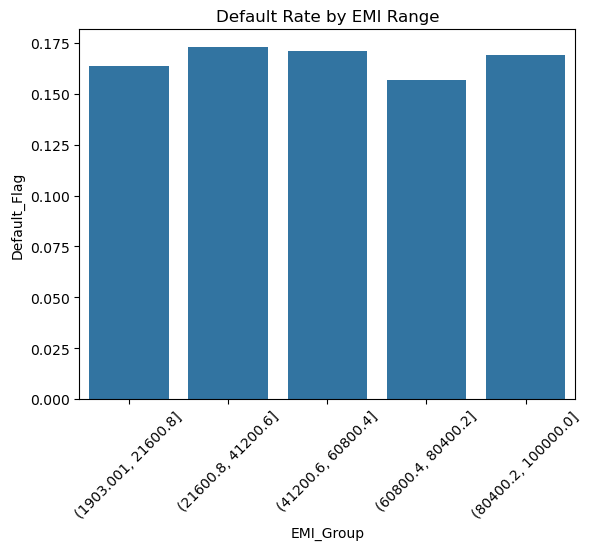

In [57]:
# Create EMI buckets
df['EMI_Group'] = pd.cut(df['EMI_Amount'],
                         bins=5)

emi_default = df.groupby('EMI_Group')['Default_Flag'].mean().reset_index()

plt.figure()
sns.barplot(data=emi_default, x='EMI_Group', y='Default_Flag')
plt.title("Default Rate by EMI Range")
plt.xticks(rotation=45)
plt.show()

In [58]:
high_risk_emi = emi_default.sort_values(by='Default_Flag', ascending=False)

high_risk_emi.head()

,EMI_Group,Default_Flag
1,"(21600.8, 41200.6]",0.172938
2,"(41200.6, 60800.4]",0.171191
4,"(80400.2, 100000.0]",0.169292
0,"(1903.001, 21600.8]",0.163580
3,"(60800.4, 80400.2]",0.156635


In [59]:
print(df.columns)

Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income',
       'Credit_Score', 'Region', 'Relationship_Manager_ID',
       'Account_Tenure_Years', 'Default_ID', 'Default_Flag',
       'Default_Amount_x', 'Income_Group', 'Credit_Group', 'Default_Amount_y',
       'Recovery_Rate', 'Default_Amount', 'EMI_Group'],
      dtype='object')


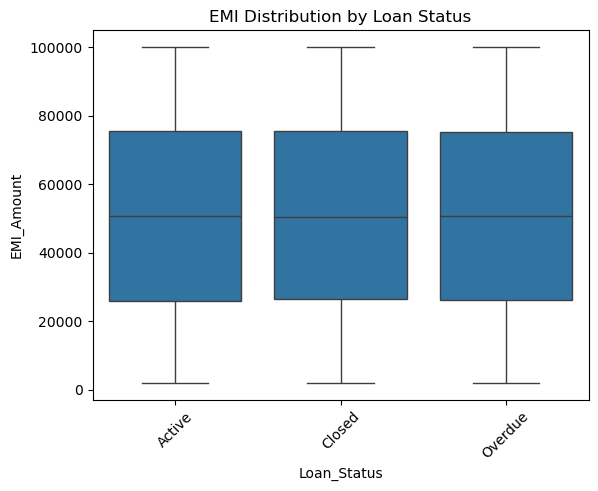

In [60]:

sns.boxplot(data=df, x='Loan_Status', y='EMI_Amount')
plt.title("EMI Distribution by Loan Status")
plt.xticks(rotation=45)
plt.show()

**TASK 9 : Loan Application Insights**

In [61]:
# Count status
status_counts = df_applications['Approval_Status'].value_counts()

print(status_counts)

# Percentage
status_percent = df_applications['Approval_Status'].value_counts(normalize=True) * 100
print(status_percent)

Approval_Status
Approved    70000
Rejected    12600
Name: count, dtype: int64
Approval_Status
Approved    84.745763
Rejected    15.254237
Name: proportion, dtype: float64


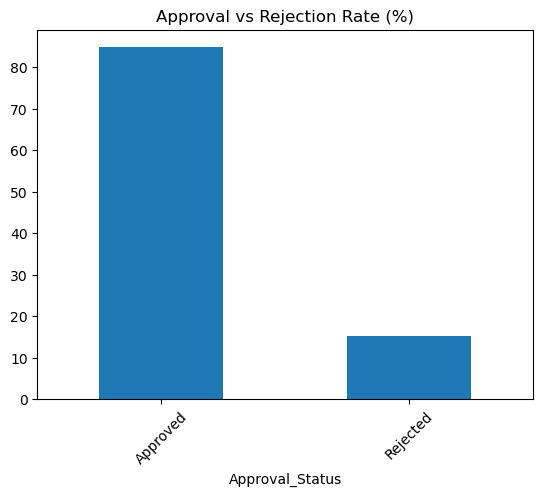

In [62]:
status_percent.plot(kind='bar')
plt.title("Approval vs Rejection Rate (%)")
plt.xticks(rotation=45)
plt.show()

In [63]:
rejected = df_applications[df_applications['Approval_Status'] == 'Rejected']

In [64]:
reason_counts = rejected['Rejection_Reason'].value_counts()

print(reason_counts)

Rejection_Reason
Low Credit Score        4297
Incomplete Documents    4204
Insufficient Income     4099
Name: count, dtype: int64


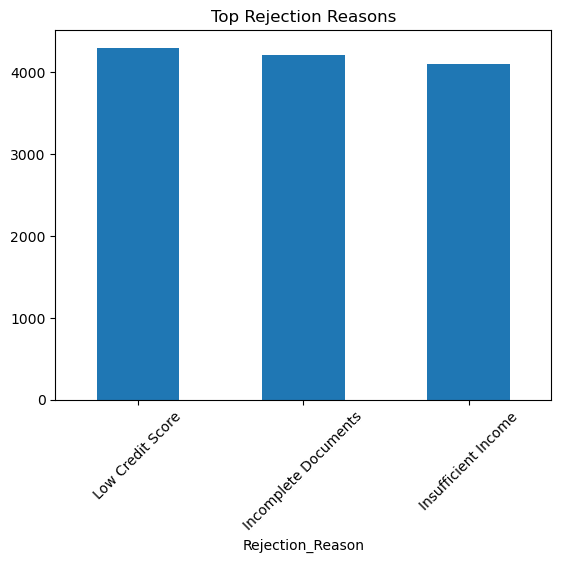

In [65]:
reason_counts.head(10).plot(kind='bar')
plt.title("Top Rejection Reasons")
plt.xticks(rotation=45)
plt.show()

In [66]:
print(df_applications.columns)

Index(['Application_ID', 'Loan_ID', 'Customer_ID', 'Application_Date',
       'Approval_Date', 'Loan_Purpose', 'Source_Channel', 'Processing_Fee',
       'Approval_Status', 'Rejection_Reason'],
      dtype='object')


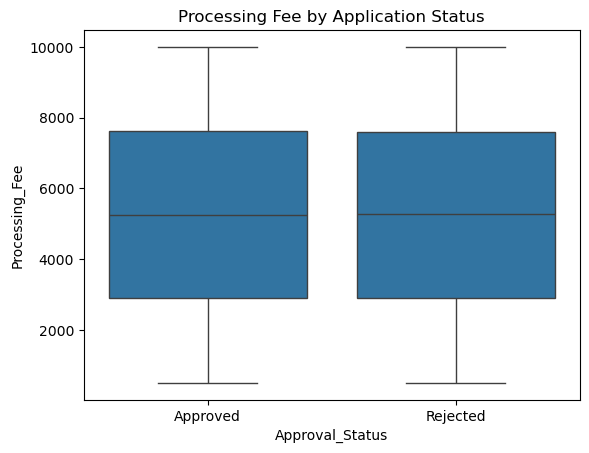

In [67]:
sns.boxplot(data=df_applications, x='Approval_Status', y='Processing_Fee')
plt.title("Processing Fee by Application Status")
plt.show()

**TASK 11 :  Loan Disbursement Efficiency**

In [68]:
df_applications['Application_Date'] = pd.to_datetime(df_applications['Application_Date'], errors='coerce')
df['Disbursal_Date'] = pd.to_datetime(df['Disbursal_Date'], errors='coerce')

In [69]:
df['Disbursal_Date'] = pd.to_datetime(df['Disbursal_Date'], errors='coerce')
df['Repayment_Start_Date'] = pd.to_datetime(df['Repayment_Start_Date'], errors='coerce')

In [70]:
df['Processing_Time'] = (df['Disbursal_Date'] - df['Repayment_Start_Date']).dt.days

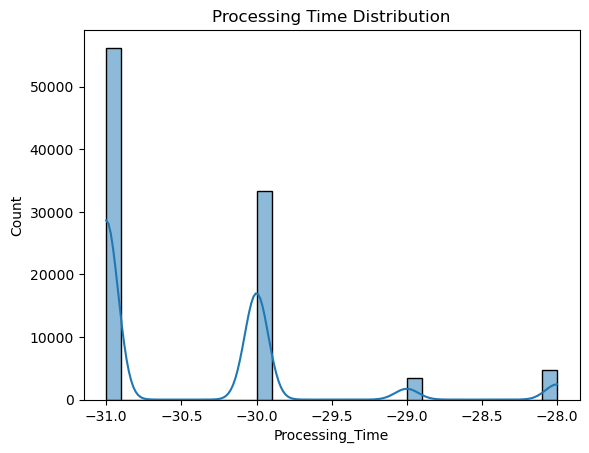

In [71]:
sns.histplot(df['Processing_Time'].dropna(), bins=30, kde=True)
plt.title("Processing Time Distribution")
plt.show()

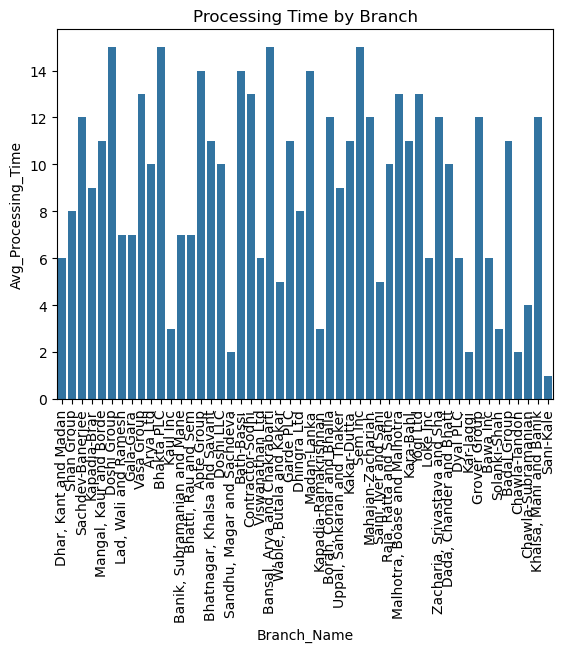

In [72]:
branch_time = df_branches[['Branch_Name','Avg_Processing_Time']]

sns.barplot(data=branch_time, x='Branch_Name', y='Avg_Processing_Time')
plt.title("Processing Time by Branch")
plt.xticks(rotation=90)
plt.show()

In [73]:
slow_branches = df_branches.sort_values(by='Avg_Processing_Time', ascending=False)

slow_branches.head()

,Branch_ID,Branch_Name,Region,Total_Customers,Total_Active_Loans,Delinquent_Loans,Loan_Disbursement_Amount,Avg_Processing_Time,Relationship_Manager_Count,Default_Rate
10,B011,Bhakta PLC,South,4108,1067,91,149799582,15,18,0.085286
30,B031,Sem Inc,South,2816,776,22,180725549,15,11,0.028351
21,B022,"Bansal, Arya and Chakrabarti",East,4214,946,114,362728718,15,23,0.120507
5,B006,Doshi Group,North,525,856,76,10435197,15,7,0.088785
25,B026,Madan-Lanka,North,3567,1677,139,401253151,14,19,0.082886


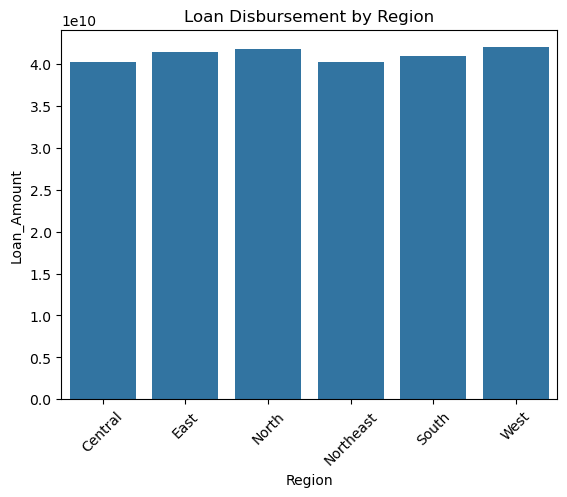

In [74]:
region_disb = df.groupby('Region')['Loan_Amount'].sum().reset_index()

sns.barplot(data=region_disb, x='Region', y='Loan_Amount')
plt.title("Loan Disbursement by Region")
plt.xticks(rotation=45)
plt.show()

In [75]:
print(df.columns)

Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income',
       'Credit_Score', 'Region', 'Relationship_Manager_ID',
       'Account_Tenure_Years', 'Default_ID', 'Default_Flag',
       'Default_Amount_x', 'Income_Group', 'Credit_Group', 'Default_Amount_y',
       'Recovery_Rate', 'Default_Amount', 'EMI_Group', 'Processing_Time'],
      dtype='object')


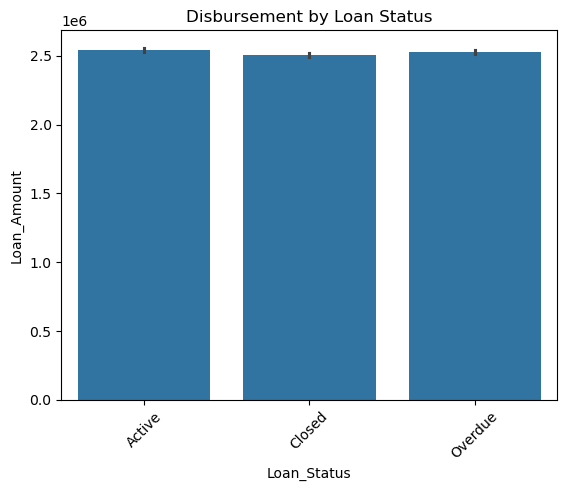

In [76]:
sns.barplot(data=df, x='Loan_Status', y='Loan_Amount')
plt.title("Disbursement by Loan Status")
plt.xticks(rotation=45)
plt.show()

**TASK 14 :  Default Trends**

In [77]:
df_defaults['Default_Date'] = pd.to_datetime(df_defaults['Default_Date'], errors='coerce')

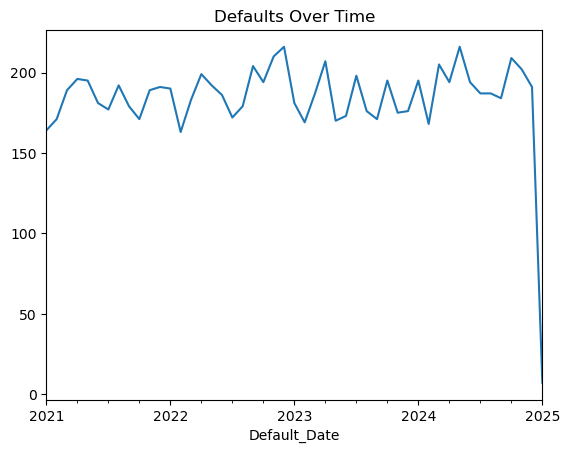

In [78]:
monthly_defaults = df_defaults.groupby(
    df_defaults['Default_Date'].dt.to_period('M')
).size()

monthly_defaults.plot()
plt.title("Defaults Over Time")
plt.show()

In [79]:
print(df.columns)

Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income',
       'Credit_Score', 'Region', 'Relationship_Manager_ID',
       'Account_Tenure_Years', 'Default_ID', 'Default_Flag',
       'Default_Amount_x', 'Income_Group', 'Credit_Group', 'Default_Amount_y',
       'Recovery_Rate', 'Default_Amount', 'EMI_Group', 'Processing_Time'],
      dtype='object')


In [80]:
df_default = df.copy()

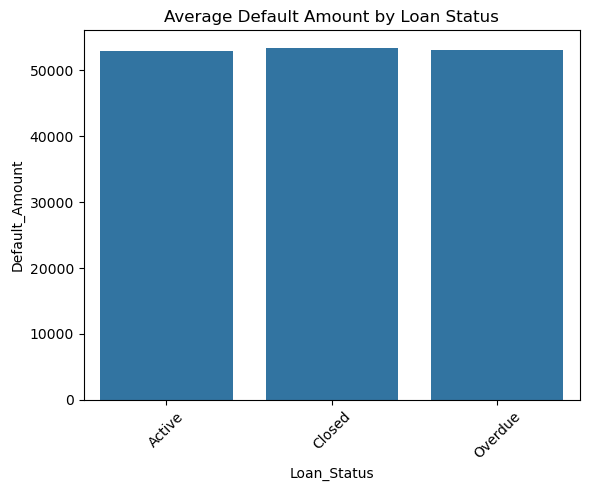

In [81]:
purpose_default = df_default.groupby('Loan_Status')['Default_Amount'].mean().reset_index()

sns.barplot(data=purpose_default, x='Loan_Status', y='Default_Amount')
plt.title("Average Default Amount by Loan Status")
plt.xticks(rotation=45)
plt.show()

In [82]:
df['Income_Group'] = pd.cut(df['Annual_Income'],
                           bins=[0,500000,1000000,5000000],
                           labels=['Low','Medium','High'])

df['Default_Flag'] = df['Default_ID'].notna().astype(int)

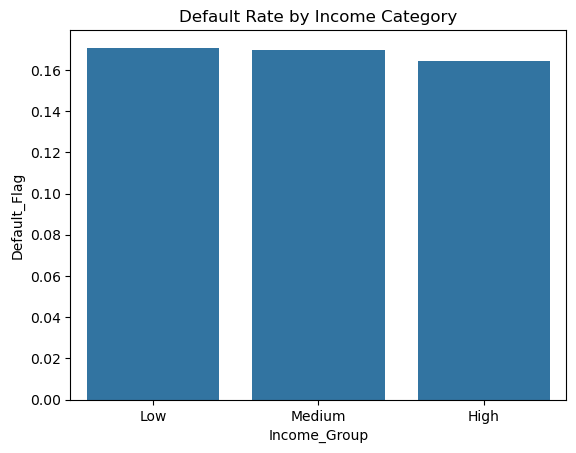

In [83]:
income_default = df.groupby('Income_Group')['Default_Flag'].mean().reset_index()

sns.barplot(data=income_default, x='Income_Group', y='Default_Flag')
plt.title("Default Rate by Income Category")
plt.show()

**TASK 17 :  Customer Behavior Analysis**

In [84]:
df['Default_Flag'] = df['Default_ID'].notna().astype(int)

# Categorize behavior
def categorize_behavior(x):
    if x == 0:
        return "Always On Time"
    elif x == 1:
        return "Occasional Defaulter"
    else:
        return "Frequent Defaulter"

df['Repayment_Behavior'] = df['Default_Flag'].apply(categorize_behavior)

# Count
df['Repayment_Behavior'].value_counts()

Repayment_Behavior
Always On Time          81461
Occasional Defaulter    16304
Name: count, dtype: int64

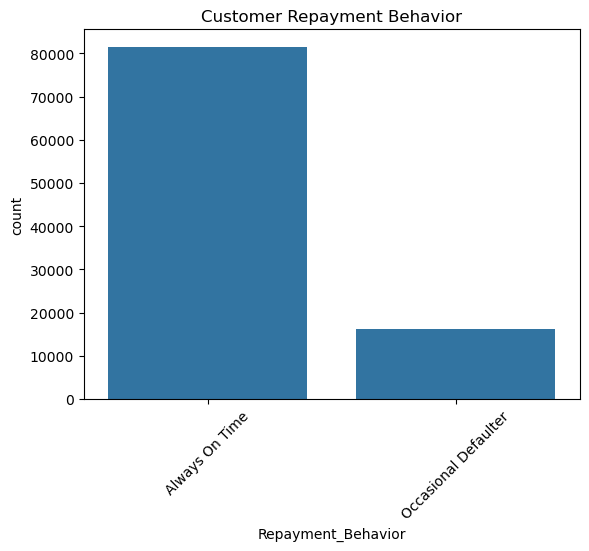

In [85]:
sns.countplot(data=df, x='Repayment_Behavior')
plt.title("Customer Repayment Behavior")
plt.xticks(rotation=45)
plt.show()

In [86]:
app_df = df_applications.merge(df_customers, on='Customer_ID', how='left')

In [87]:
app_df['Income_Group'] = pd.cut(app_df['Annual_Income'],
                               bins=[0,500000,1000000,5000000],
                               labels=['Low','Medium','High'])

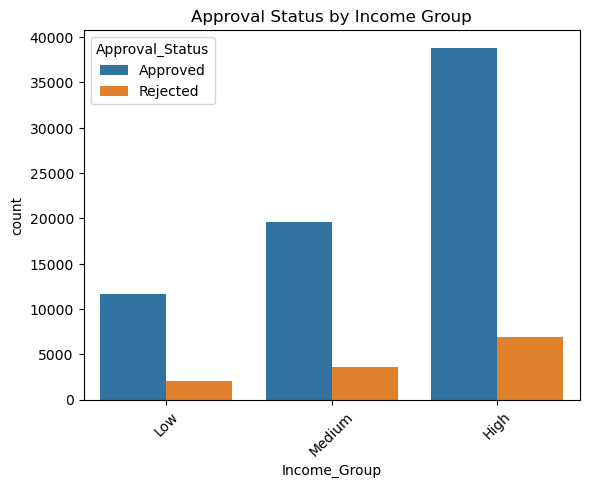

In [88]:
sns.countplot(data=app_df, x='Income_Group', hue='Approval_Status')
plt.title("Approval Status by Income Group")
plt.xticks(rotation=45)
plt.show()

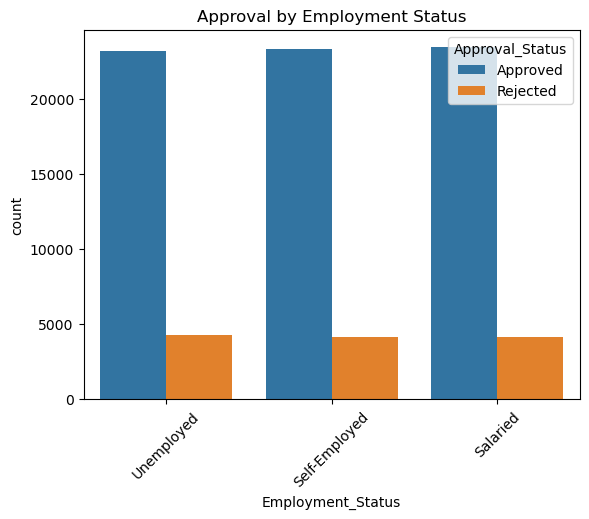

In [89]:
sns.countplot(data=app_df, x='Employment_Status', hue='Approval_Status')
plt.title("Approval by Employment Status")
plt.xticks(rotation=45)
plt.show()

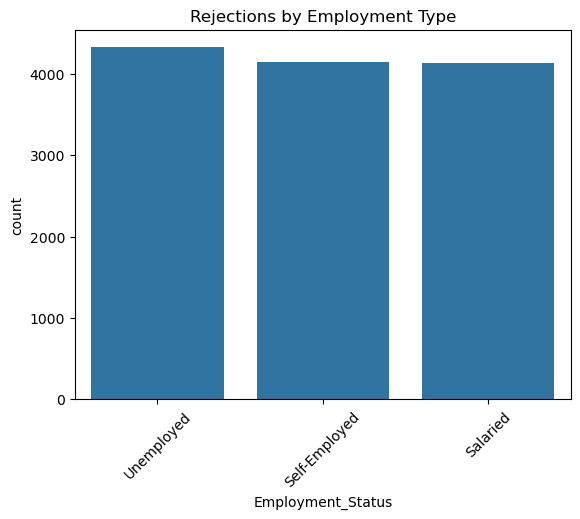

In [90]:
rejected = app_df[app_df['Approval_Status'] == 'Rejected']

sns.countplot(data=rejected, x='Employment_Status')
plt.title("Rejections by Employment Type")
plt.xticks(rotation=45)
plt.show()

In [91]:
high_value = df[
    (df['Credit_Score'] > 750) &
    (df['Annual_Income'] > 1000000) &
    (df['Default_Flag'] == 0)
]

print("High Value Customers:", high_value.shape[0])

High Value Customers: 8239


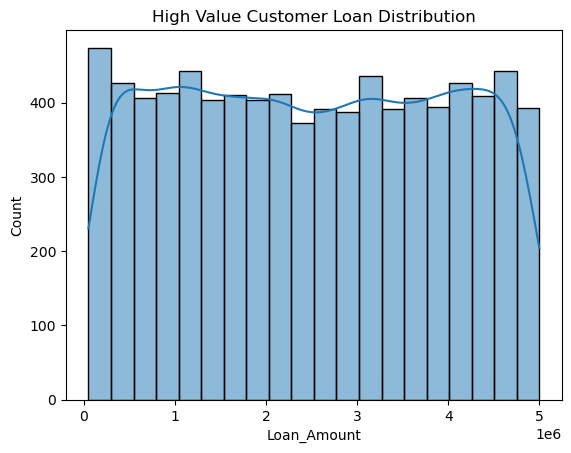

In [92]:
sns.histplot(high_value['Loan_Amount'], bins=20, kde=True)
plt.title("High Value Customer Loan Distribution")
plt.show()

**TASK 18 :  Risk Assessment**

In [93]:
df['Default_Flag'] = df['Default_ID'].notna().astype(int)

# Create a simple risk score (normalized-style)
df['Risk_Score'] = (
    df['Default_Flag'] * 3 + 
    (df['Interest_Rate'] / df['Interest_Rate'].max()) * 2 +
    (df['Loan_Term'] / df['Loan_Term'].max()) * 2
)

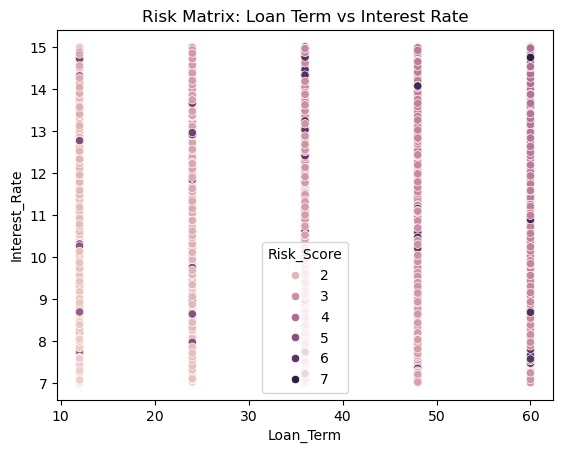

In [94]:
plt.figure()
sns.scatterplot(data=df, x='Loan_Term', y='Interest_Rate', hue='Risk_Score')
plt.title("Risk Matrix: Loan Term vs Interest Rate")
plt.show()

In [95]:
print(df.columns)

Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income',
       'Credit_Score', 'Region', 'Relationship_Manager_ID',
       'Account_Tenure_Years', 'Default_ID', 'Default_Flag',
       'Default_Amount_x', 'Income_Group', 'Credit_Group', 'Default_Amount_y',
       'Recovery_Rate', 'Default_Amount', 'EMI_Group', 'Processing_Time',
       'Repayment_Behavior', 'Risk_Score'],
      dtype='object')


In [96]:
loan_risk = df.groupby('Loan_Status')['Risk_Score'].mean().reset_index()

loan_risk = loan_risk.sort_values(by='Risk_Score', ascending=False)

loan_risk

,Loan_Status,Risk_Score
2,Overdue,3.188151
0,Active,3.170797
1,Closed,3.137576


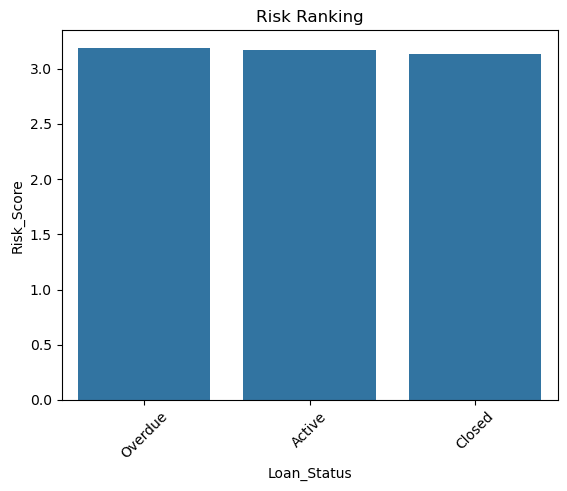

In [97]:
sns.barplot(data=loan_risk, x=loan_risk.columns[0], y='Risk_Score')
plt.title("Risk Ranking")
plt.xticks(rotation=45)
plt.show()

In [98]:
df['Income_Group'] = pd.cut(df['Annual_Income'],
                           bins=[0,500000,1000000,5000000],
                           labels=['Low','Medium','High'])

df['Credit_Group'] = pd.cut(df['Credit_Score'],
                           bins=[0,600,750,900],
                           labels=['Low','Medium','High'])

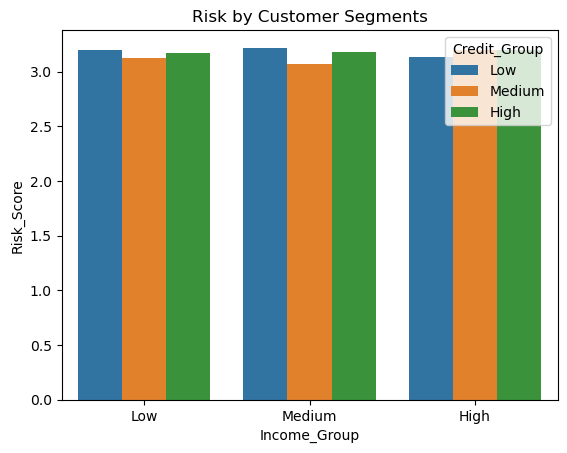

In [99]:
segment_risk = df.groupby(['Income_Group','Credit_Group'])['Risk_Score'].mean().reset_index()

sns.barplot(data=segment_risk, x='Income_Group', y='Risk_Score', hue='Credit_Group')
plt.title("Risk by Customer Segments")
plt.show()

**TASK 19 :  Time to Default Analysis**

In [100]:
df['Disbursal_Date'] = pd.to_datetime(df['Disbursal_Date'], errors='coerce')
df_defaults['Default_Date'] = pd.to_datetime(df_defaults['Default_Date'], errors='coerce')

In [101]:
df_time = df.merge(df_defaults[['Loan_ID','Default_Date']], on='Loan_ID', how='left')

In [102]:
df_time['Time_To_Default'] = (df_time['Default_Date'] - df_time['Disbursal_Date']).dt.days

df_time['Time_To_Default'].describe()

count    25890.000000
mean       238.987331
std        666.365626
min      -1426.000000
25%       -225.000000
50%        259.000000
75%        721.000000
max       1809.000000
Name: Time_To_Default, dtype: float64

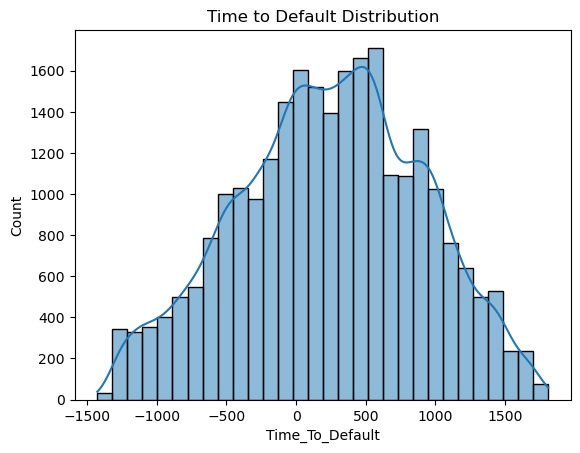

In [103]:
sns.histplot(df_time['Time_To_Default'].dropna(), bins=30, kde=True)
plt.title("Time to Default Distribution")
plt.show()

In [104]:
print("Average Time to Default:", df_time['Time_To_Default'].mean())

Average Time to Default: 238.98733101583622


In [105]:
print(df.columns)

Index(['Loan_ID', 'Customer_ID', 'Loan_Amount', 'Interest_Rate', 'Loan_Term',
       'Disbursal_Date', 'Repayment_Start_Date', 'Repayment_End_Date',
       'Loan_Status', 'Overdue_Amount', 'EMI_Amount', 'Collateral_Details',
       'Age', 'Gender', 'Marital_Status', 'Employment_Status', 'Annual_Income',
       'Credit_Score', 'Region', 'Relationship_Manager_ID',
       'Account_Tenure_Years', 'Default_ID', 'Default_Flag',
       'Default_Amount_x', 'Income_Group', 'Credit_Group', 'Default_Amount_y',
       'Recovery_Rate', 'Default_Amount', 'EMI_Group', 'Processing_Time',
       'Repayment_Behavior', 'Risk_Score'],
      dtype='object')


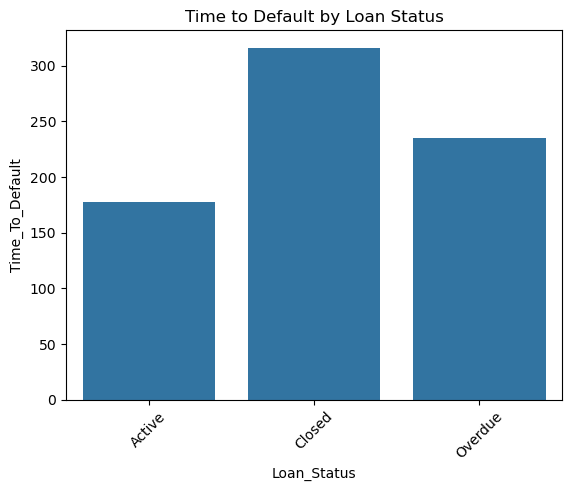

In [106]:
purpose_time = df_time.groupby('Loan_Status')['Time_To_Default'].mean().reset_index()

sns.barplot(data=purpose_time, x='Loan_Status', y='Time_To_Default')
plt.title("Time to Default by Loan Status")
plt.xticks(rotation=45)
plt.show()

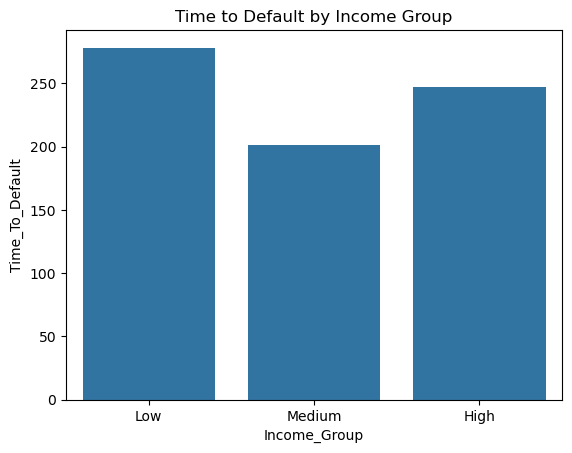

In [107]:
df_time['Income_Group'] = pd.cut(df_time['Annual_Income'],
                                bins=[0,500000,1000000,5000000],
                                labels=['Low','Medium','High'])

income_time = df_time.groupby('Income_Group')['Time_To_Default'].mean().reset_index()

sns.barplot(data=income_time, x='Income_Group', y='Time_To_Default')
plt.title("Time to Default by Income Group")
plt.show()

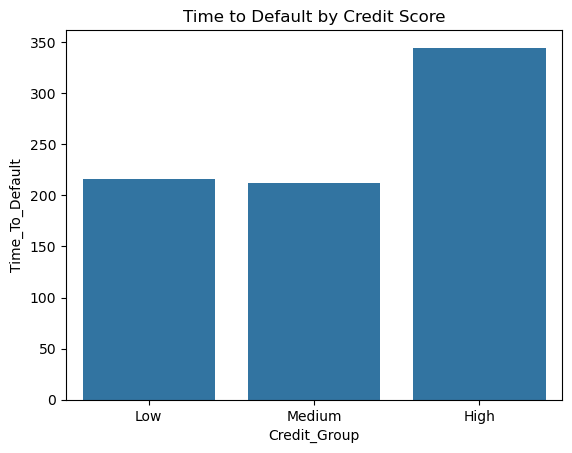

In [108]:
df_time['Credit_Group'] = pd.cut(df_time['Credit_Score'],
                                bins=[0,600,750,900],
                                labels=['Low','Medium','High'])

credit_time = df_time.groupby('Credit_Group')['Time_To_Default'].mean().reset_index()

sns.barplot(data=credit_time, x='Credit_Group', y='Time_To_Default')
plt.title("Time to Default by Credit Score")
plt.show()

**TASK 20 :  Transaction Pattern Analysis**

In [109]:
irregular = df[df['Overdue_Amount'] > 0]

irregular_customers = irregular.groupby('Customer_ID').size().reset_index(name='Count')

irregular_customers.head()

,Customer_ID,Count
0,C000003,1
1,C000005,1
2,C000011,2
3,C000012,1
4,C000013,2


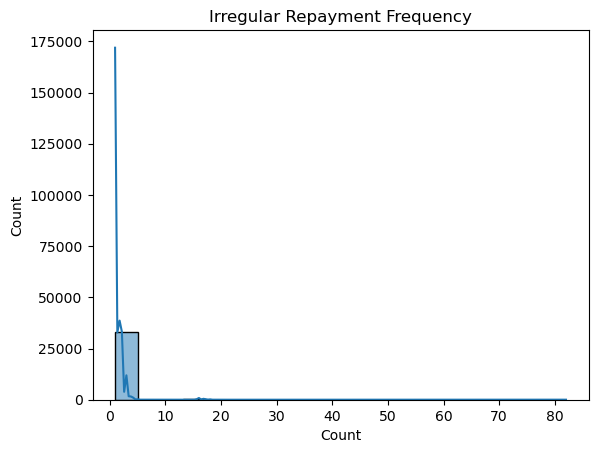

In [110]:
sns.histplot(irregular_customers['Count'], bins=20, kde=True)
plt.title("Irregular Repayment Frequency")
plt.show()

In [111]:
# Total transaction amount
total_amount = df_transactions['Amount'].sum()

# Penalty transactions
penalty_txn = df_transactions[
    df_transactions['Payment_Type'].str.contains('Penalty', case=False, na=False)
]

penalty_amount = penalty_txn['Amount'].sum()

penalty_ratio = penalty_amount / total_amount

print("Penalty Ratio:", penalty_ratio)

Penalty Ratio: 0.5006186654390998


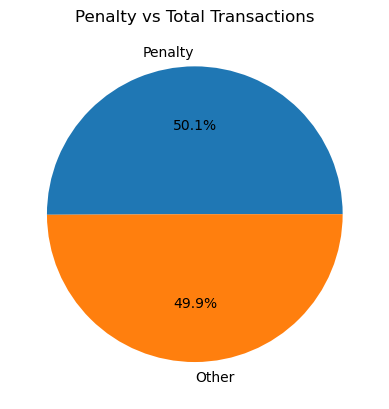

In [112]:
labels = ['Penalty', 'Other']
values = [penalty_amount, total_amount - penalty_amount]

plt.pie(values, labels=labels, autopct='%1.1f%%')
plt.title("Penalty vs Total Transactions")
plt.show()

In [113]:
df['Overdue_Flag'] = df['Overdue_Amount'] > 0

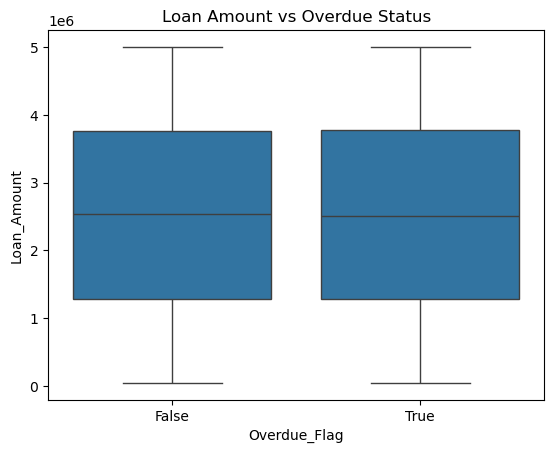

In [114]:
sns.boxplot(data=df, x='Overdue_Flag', y='Loan_Amount')
plt.title("Loan Amount vs Overdue Status")
plt.show()

In [115]:
overdue_compare = df.groupby('Overdue_Flag')['Loan_Amount'].mean().reset_index()

overdue_compare

,Overdue_Flag,Loan_Amount
0,False,2.522970e+06
1,True,2.526343e+06
